<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Statistics</p>
    <o style='font-size:20px;'>This notebook handles calculating stats for all variations and putting them into a table</p>
</div>

In [1]:
import cogsworth
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [2]:
reload(constants)
files = constants.SIMULATION_FILES

main_labels = [
    r"$f_{\rm bin} = 1.0$",
    r"$f_{\rm bin} = 0.0$",
    "No BH kicks", "No fallback rescaling", "Hobbs2005",
    "Fryer2012 Rapid", r"Mandel\&Muller2020", "Maltsev2025 (Default)",
    r"$f_{\rm fb} = 0.0$", r"$f_{\rm fb} = 0.25$", r"$f_{\rm fb} = 0.75$", r"$f_{\rm fb} = 1.0$",
    r"$P({\rm pf}) = 0.0$", r"$P({\rm pf}) = 1.0$",
    'Time-evolving potential'
]
mt_labels = [
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$",
]
labels = main_labels + mt_labels
mt_labels = [main_labels[0]] + mt_labels  # include the fiducial model in the MT section

In [3]:
plot_labels = [
    "Fiducial",
    "Singles",
    "No BH kicks",
    "No fallback rescaling",
    "Hobbs2005",
    "Fryer2012 Rapid", r"Mandel&Muller2020", "Maltsev2025 (Default)",
    r"Maltsev2025 ($f_{\rm fb} = 0.0$)", r"Maltsev2025 ($f_{\rm fb} = 0.25$)", r"Maltsev2025 ($f_{\rm fb} = 0.75$)", r"Maltsev2025 ($f_{\rm fb} = 1.0$)",
    r"Maltsev2025 ($P({\rm pf}) = 0.0$)", r"Maltsev2025 ($P({\rm pf}) = 1.0$)",
    'Time-evolving potential',
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$"
]

In [5]:
reload(helpers)
pops, data = helpers.load_postprocessed_pops(files, labels, [None] * len(files))

In [6]:
x = cogsworth.pop.load(f"/mnt/ceph/users/twagg/underworld/fiducial_m2min/fiducial_m2min_part{0}.h5")
x.final_pos

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:2005: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  p = Population(



<Quantity [[ 6.82684441e+00,  4.14656557e+00,  3.48543103e+00],
           [-4.18098644e+01,  3.57790612e+01,  6.07013330e-01],
           [-9.24674610e+00, -1.33652062e+01, -4.81943623e-01],
           ...,
           [ 6.23177978e+00, -2.00362465e+00, -2.55269511e+00],
           [-3.77779165e+00,  6.30371860e+00, -4.20709979e-01],
           [ 1.54021905e+03, -1.43401290e+03, -3.59064585e+02]] kpc>

In [8]:
y = x[(x.final_bpp["kstar_1"] == 14) | (x.final_bpp["kstar_2"] == 14)]
y.save("/mnt/ceph/users/twagg/underworld/fiducial_m2min/fiducial_m2min_part0_test.h5", overwrite=True)

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(



In [117]:
co_pops = [cogsworth.pop.load(f"/mnt/ceph/users/twagg/underworld/fiducial_m2min/fiducial_m2min_co_plus_star_part{i}.h5") for i in range(100)]

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:2005: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  p = Population(

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:2005: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  p = Population(

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:2005: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  p = Population(

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:2005: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of 

In [118]:
[pop.final_pos for pop in co_pops]
co_pop = sum(co_pops[1:], start=co_pops[0])

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will 

In [119]:
bh_star_pop = co_pop[co_pop.final_bpp["kstar_1"] == 14]

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(



In [152]:
bh_star_pop.kick_info[bh_star_pop.kick_info["star"] == 1]["natal_kick"]

9830        125.850051
12787         0.000000
14006         0.000000
21582         0.000000
26013       339.517628
               ...    
31423893    180.703027
31434654     58.980078
31453246      0.000000
31454465      0.000000
31455049      0.000000
Name: natal_kick, Length: 4909, dtype: float64

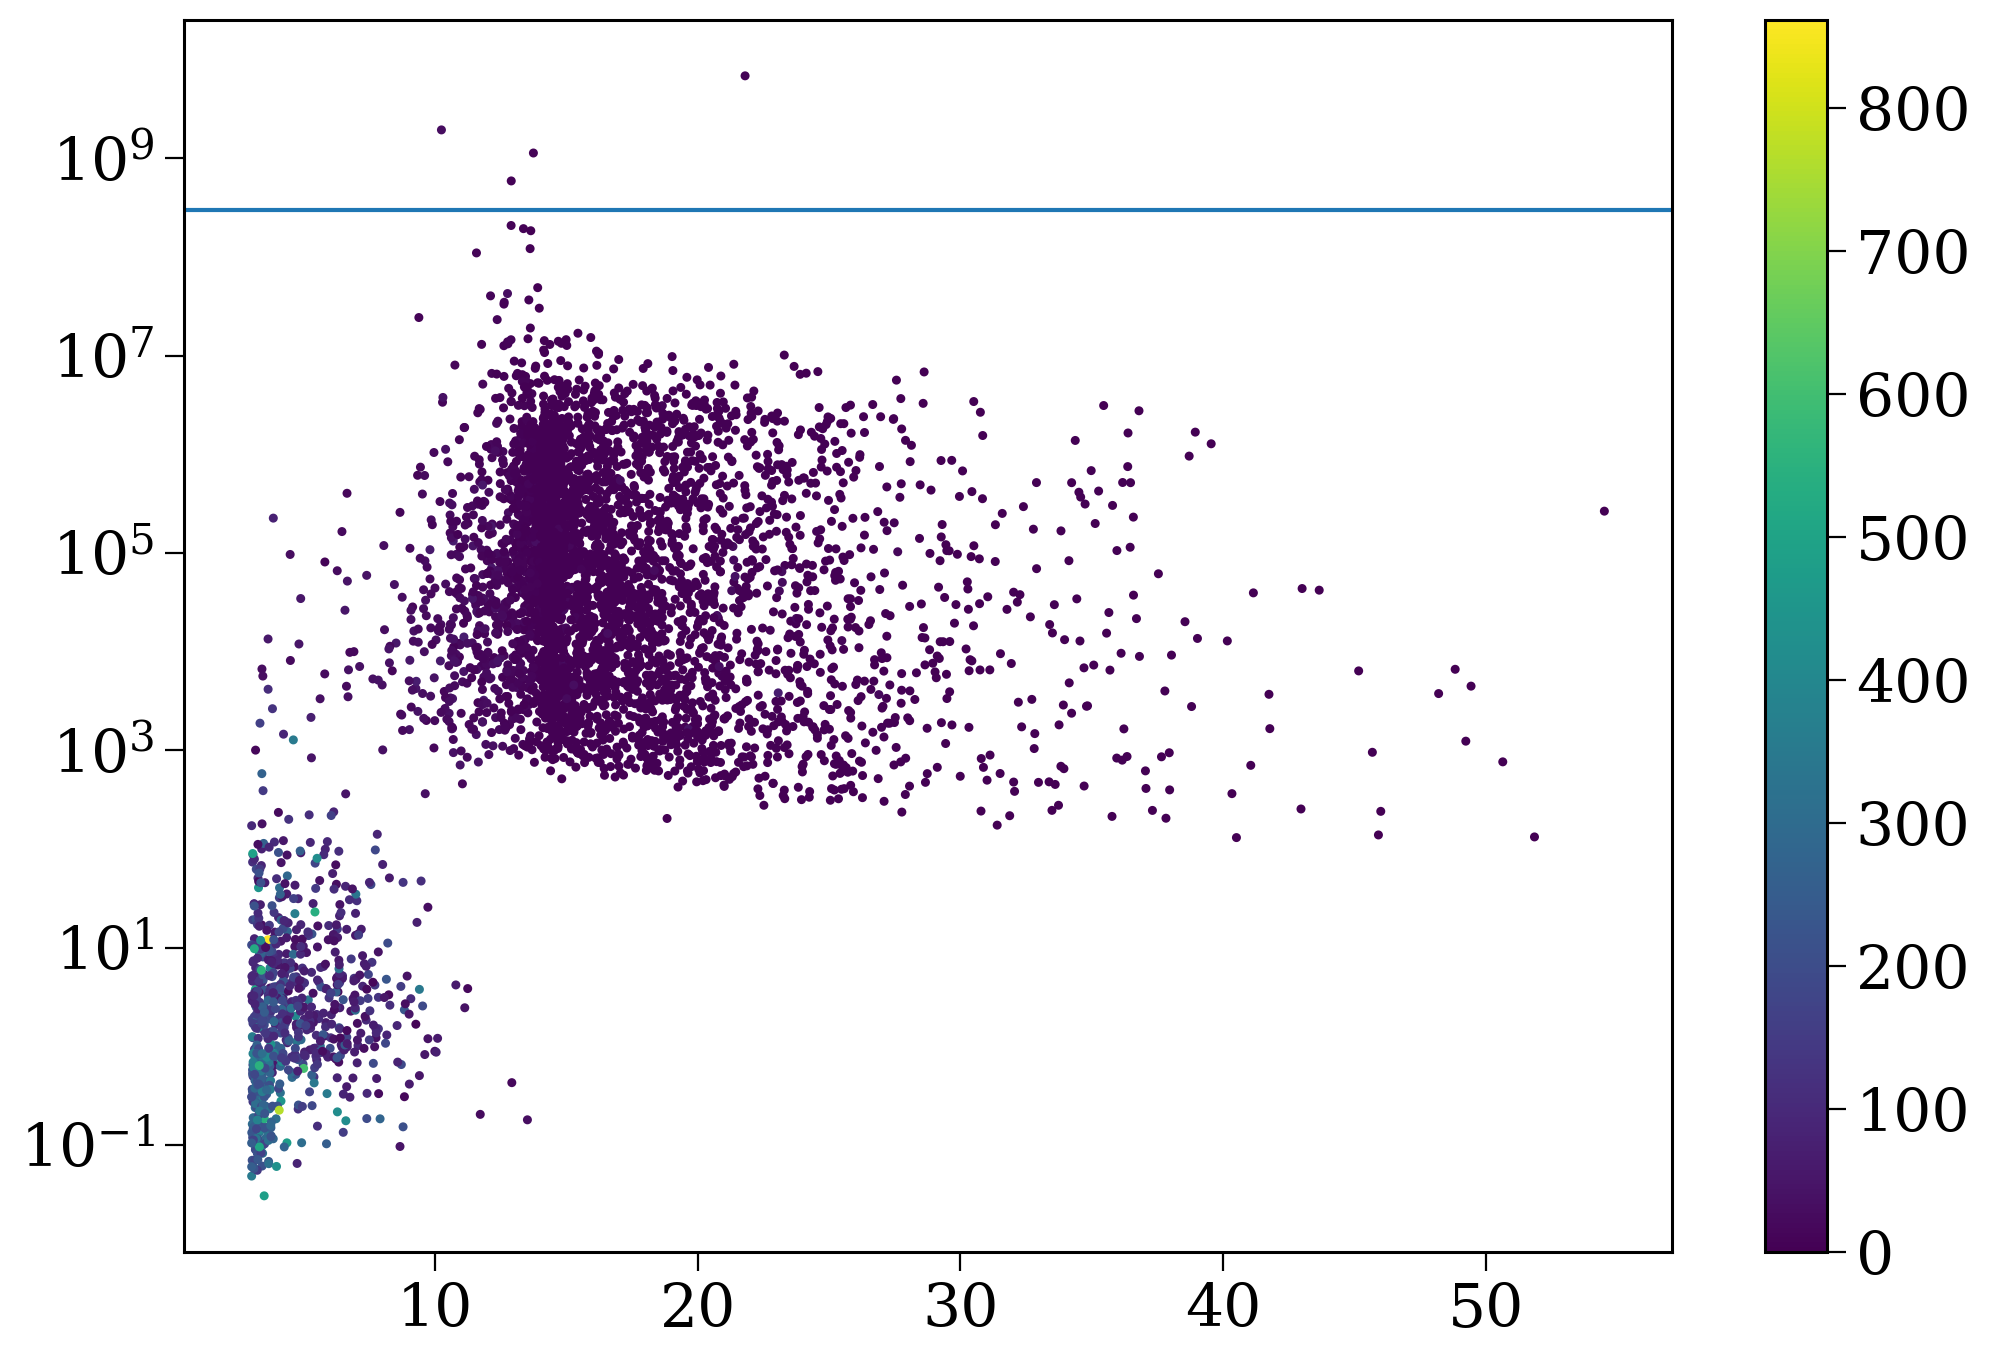

In [158]:
had_ce = np.isin(bh_star_pop.bin_nums, bh_star_pop.bpp[bh_star_pop.bpp["evol_type"] == 7]["bin_num"])
kick_strength = bh_star_pop.kick_info[bh_star_pop.kick_info["star"] == 1]["natal_kick"]
# plt.scatter(bh_star_pop.final_bpp["mass_1"], bh_star_pop.final_bpp["porb"], c=had_ce, s=5)
scatter = plt.scatter(bh_star_pop.final_bpp["mass_1"], bh_star_pop.final_bpp["porb"], c=kick_strength, s=5)
plt.colorbar(scatter)
plt.axhline(3e8)
plt.yscale("log")

<Axes: >

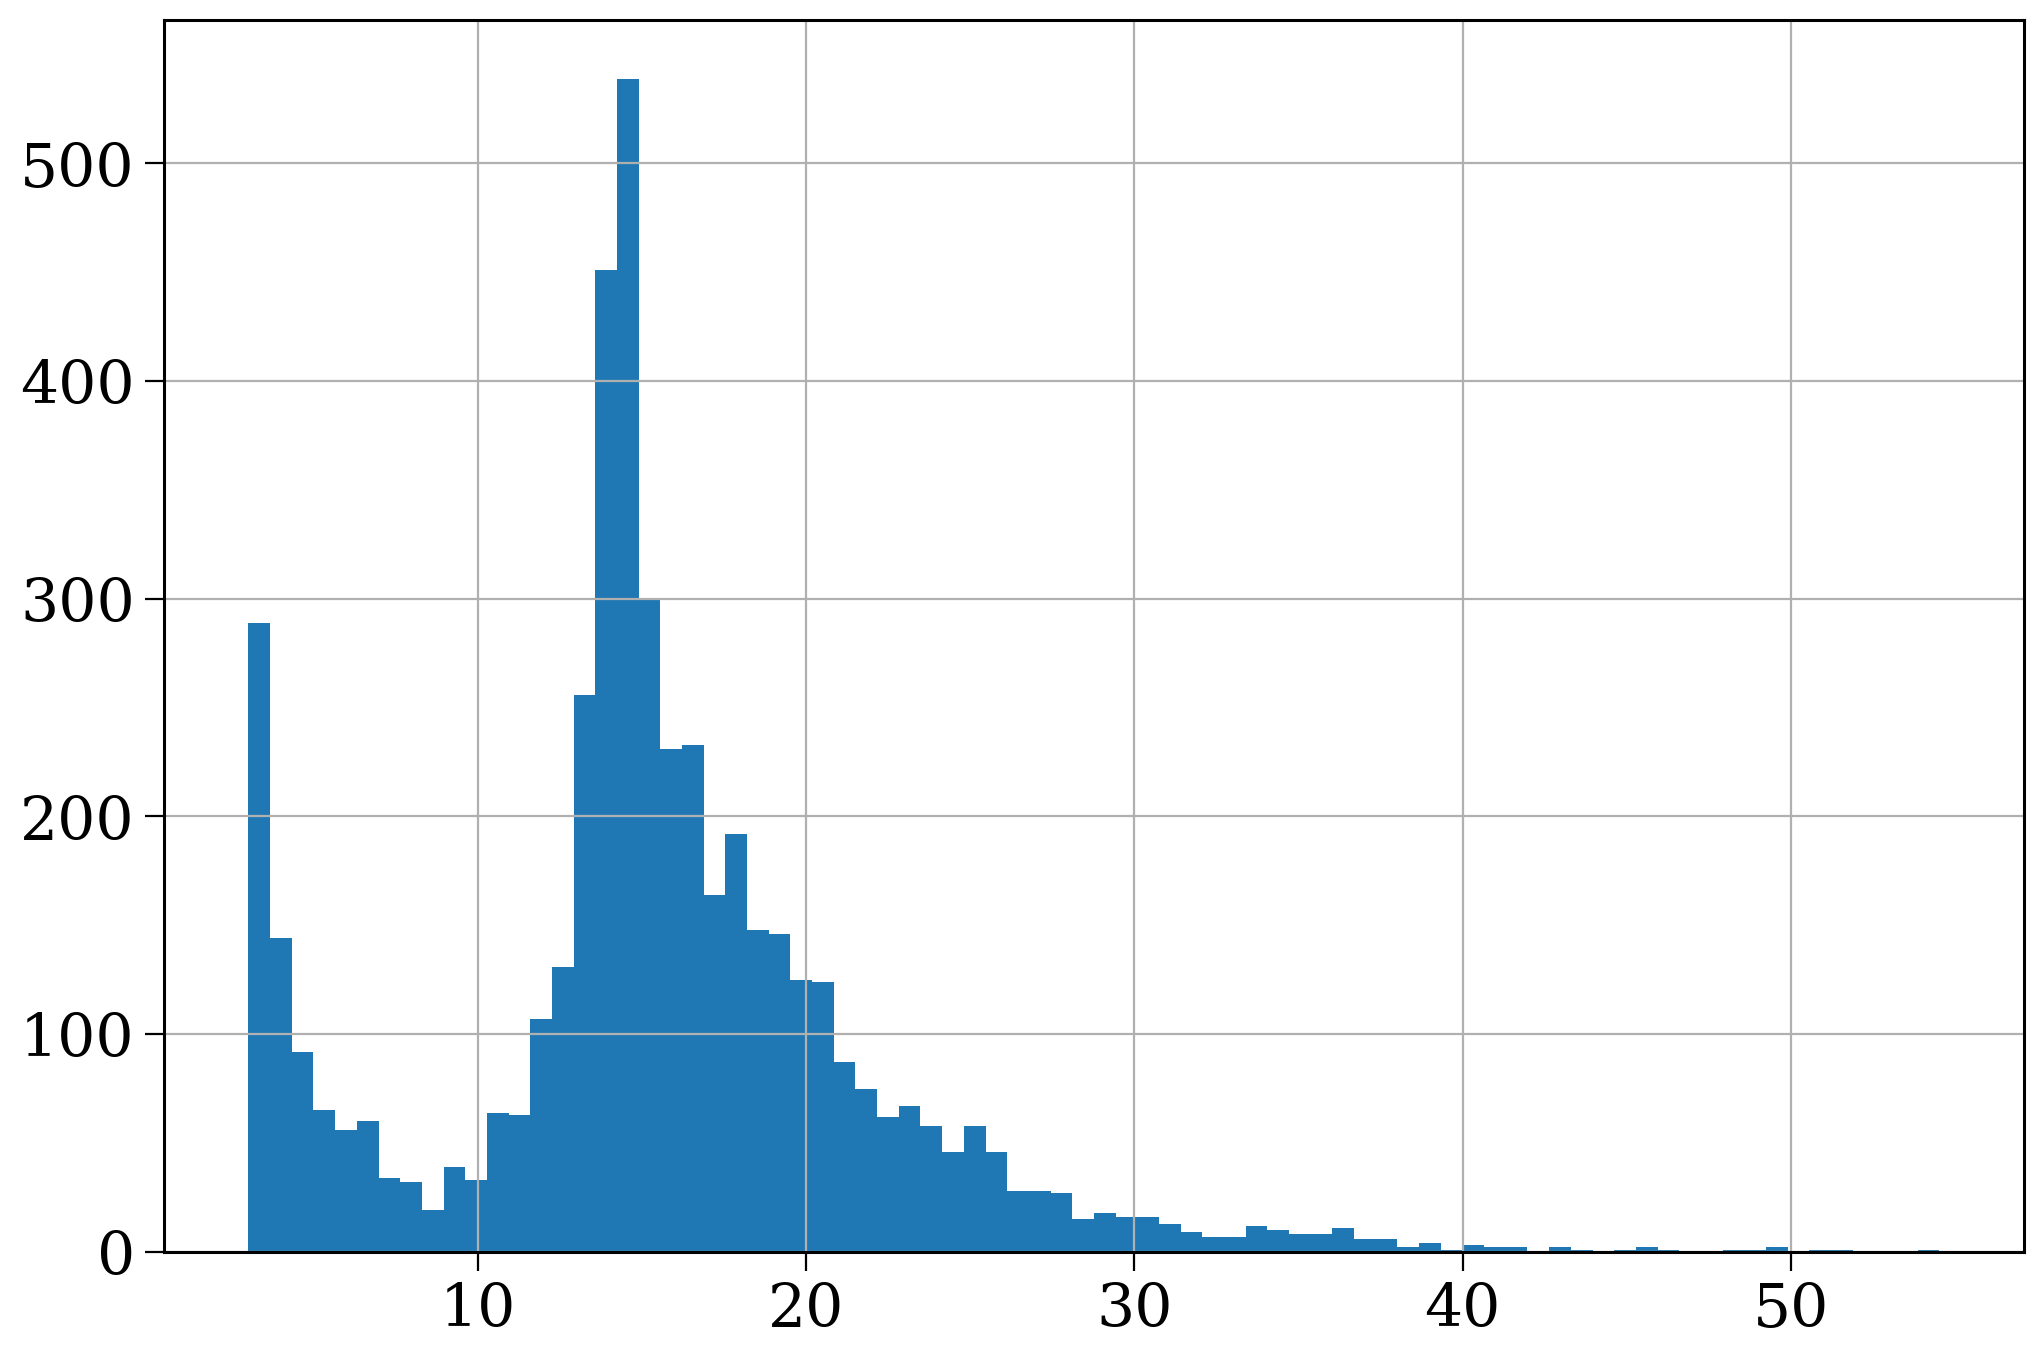

In [120]:
bh_star_pop.final_bpp["mass_1"].hist(bins="auto")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


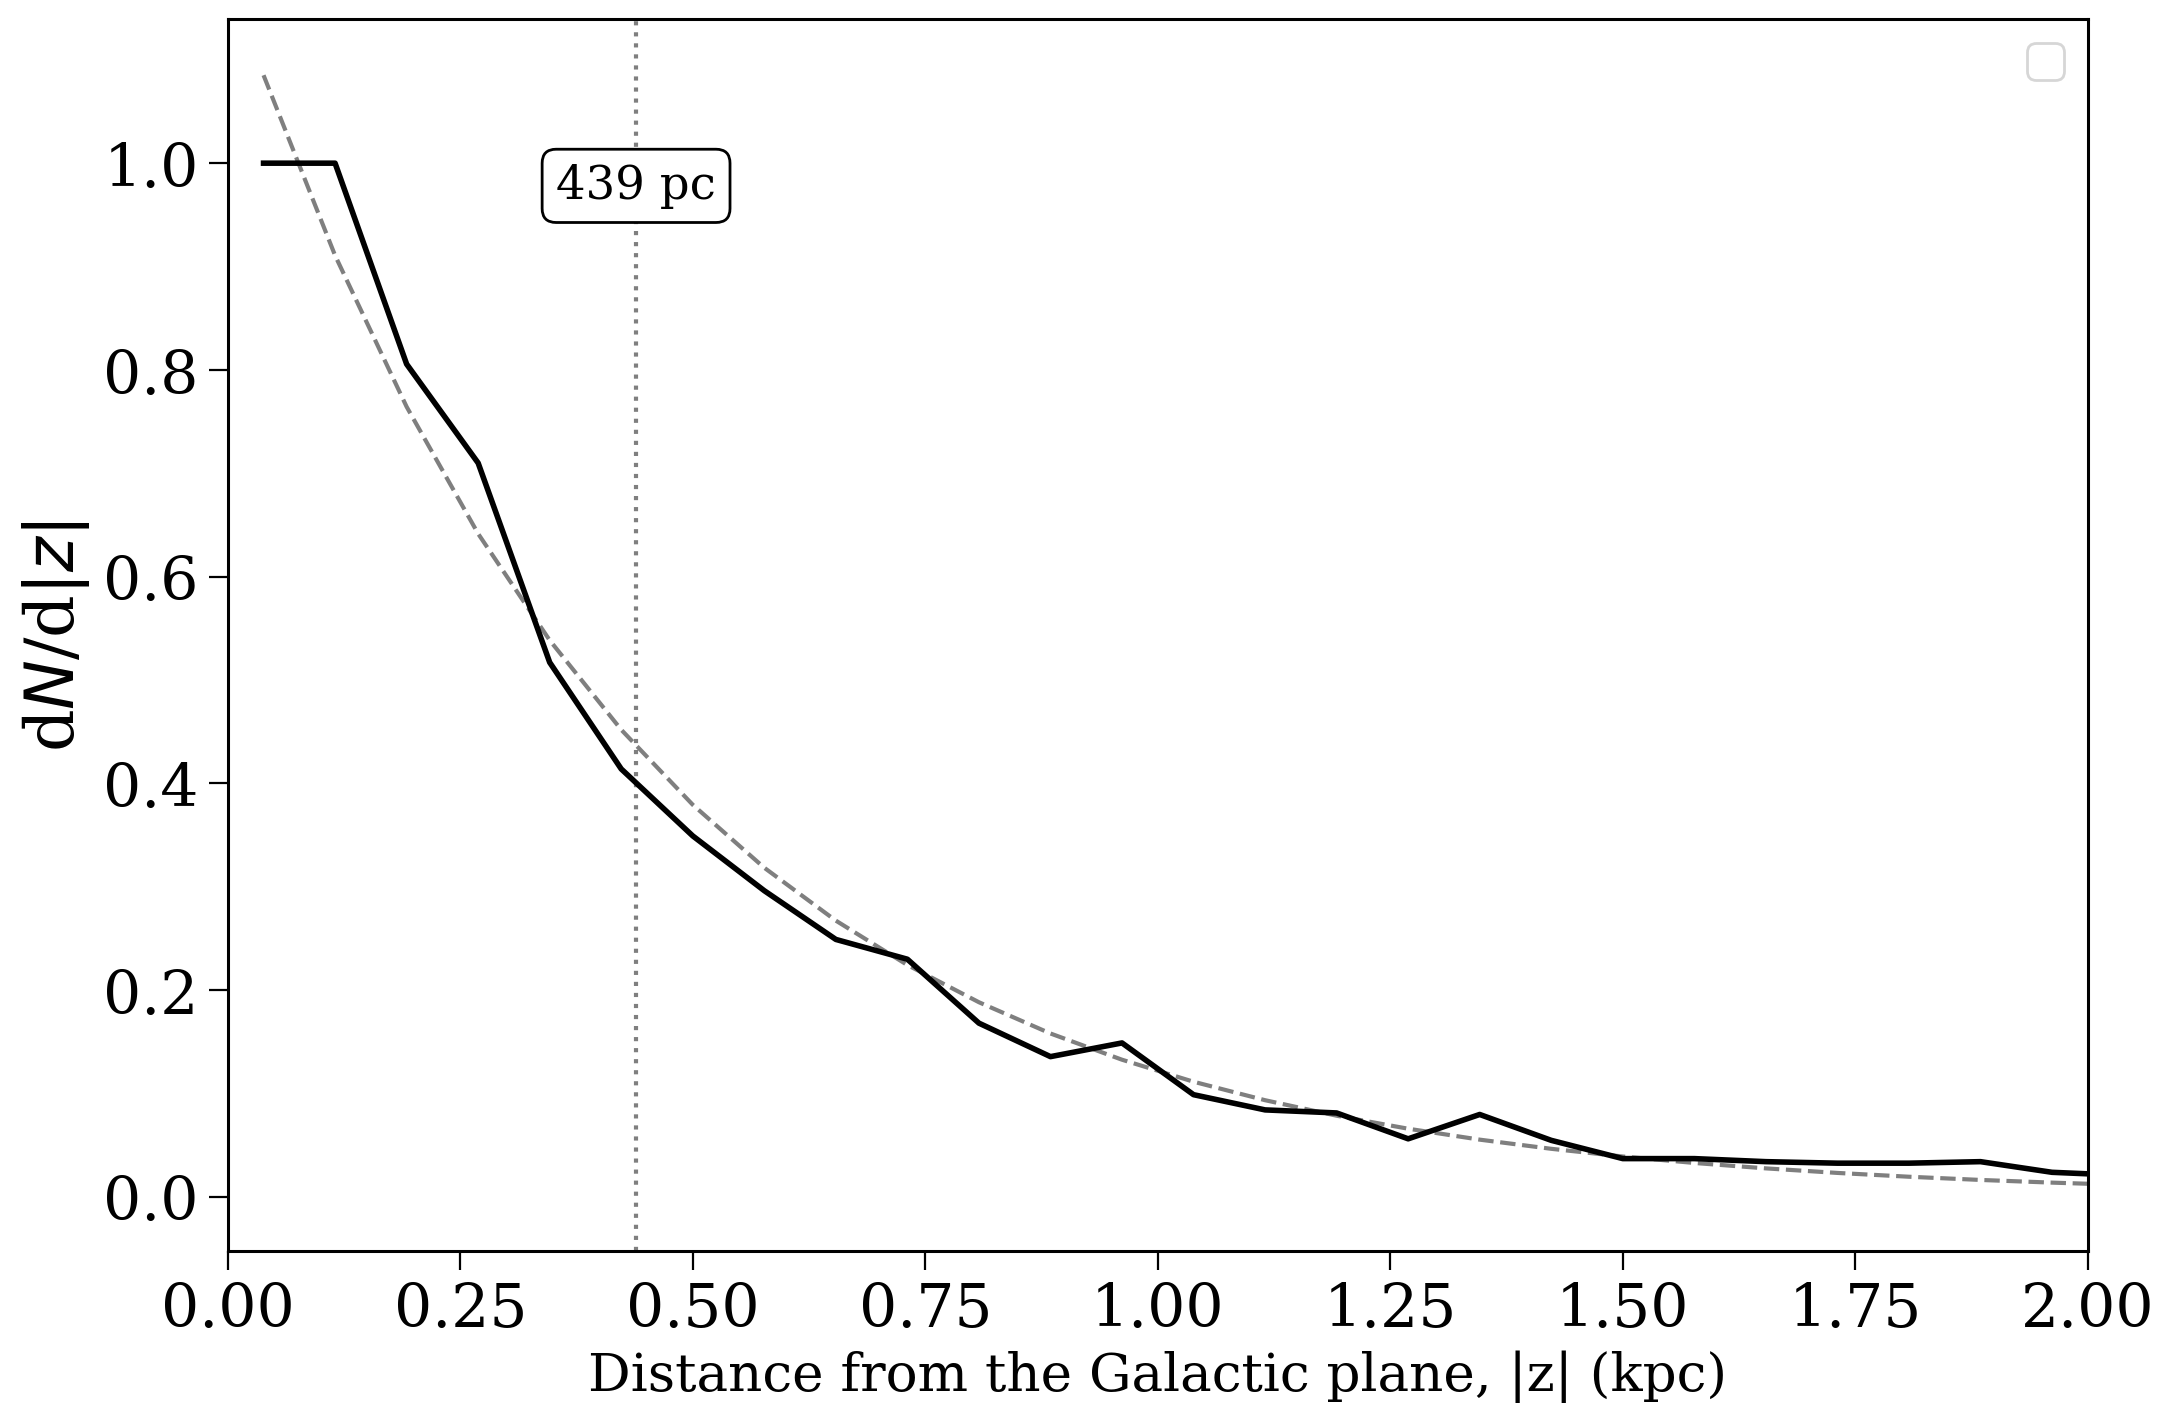

(np.float64(0.4390287805756115),
 np.float64(0.05837619745739041),
 <Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='Distance from the Galactic plane, |z| (kpc)', ylabel='d$N$/d$|z|$'>)

In [129]:
plotting.estimate_scale_height(
    bh_star_pop.final_pos[:, 2].value,
    bins=np.linspace(0, 3, 40),
    xlim=(0, 2),
    plot=True
)

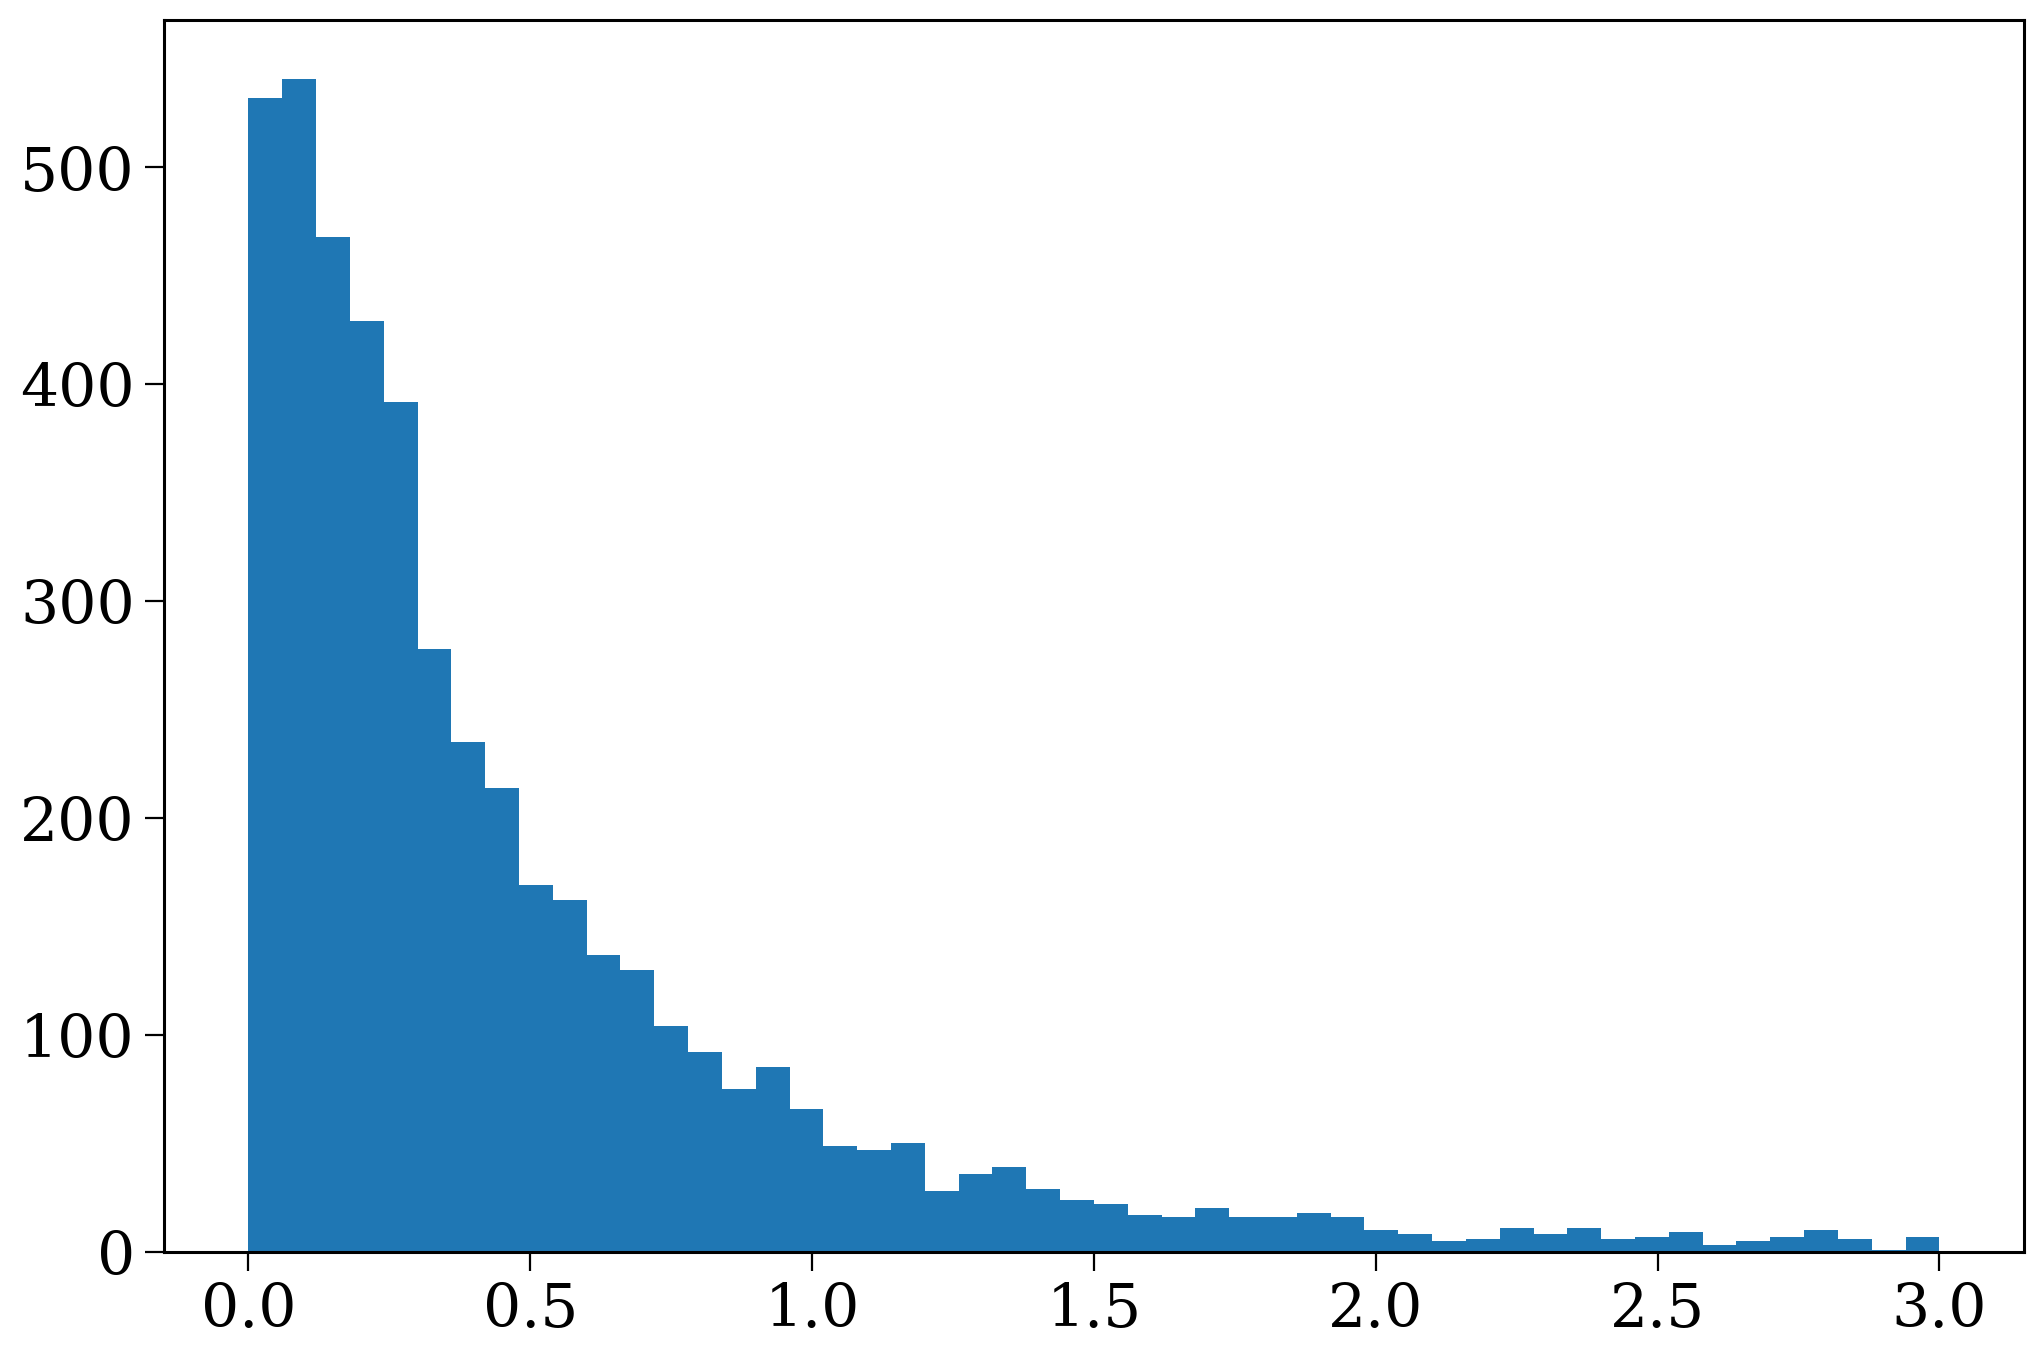

In [128]:
plt.hist(abs(bh_star_pop.final_pos[:, 2].value), bins="auto", range=(0, 3));

(array([143.,  99.,  74.,  83.,  87., 103., 111., 108., 115., 118., 136.,
        152., 166., 211., 227., 258., 342., 358., 418., 426., 446., 444.,
        284.]),
 array([4.70047284e-03, 5.20627702e-01, 1.03655493e+00, 1.55248216e+00,
        2.06840939e+00, 2.58433662e+00, 3.10026385e+00, 3.61619108e+00,
        4.13211831e+00, 4.64804554e+00, 5.16397277e+00, 5.67990000e+00,
        6.19582723e+00, 6.71175446e+00, 7.22768169e+00, 7.74360892e+00,
        8.25953615e+00, 8.77546338e+00, 9.29139060e+00, 9.80731783e+00,
        1.03232451e+01, 1.08391723e+01, 1.13550995e+01, 1.18710268e+01]),
 <BarContainer object of 23 artists>)

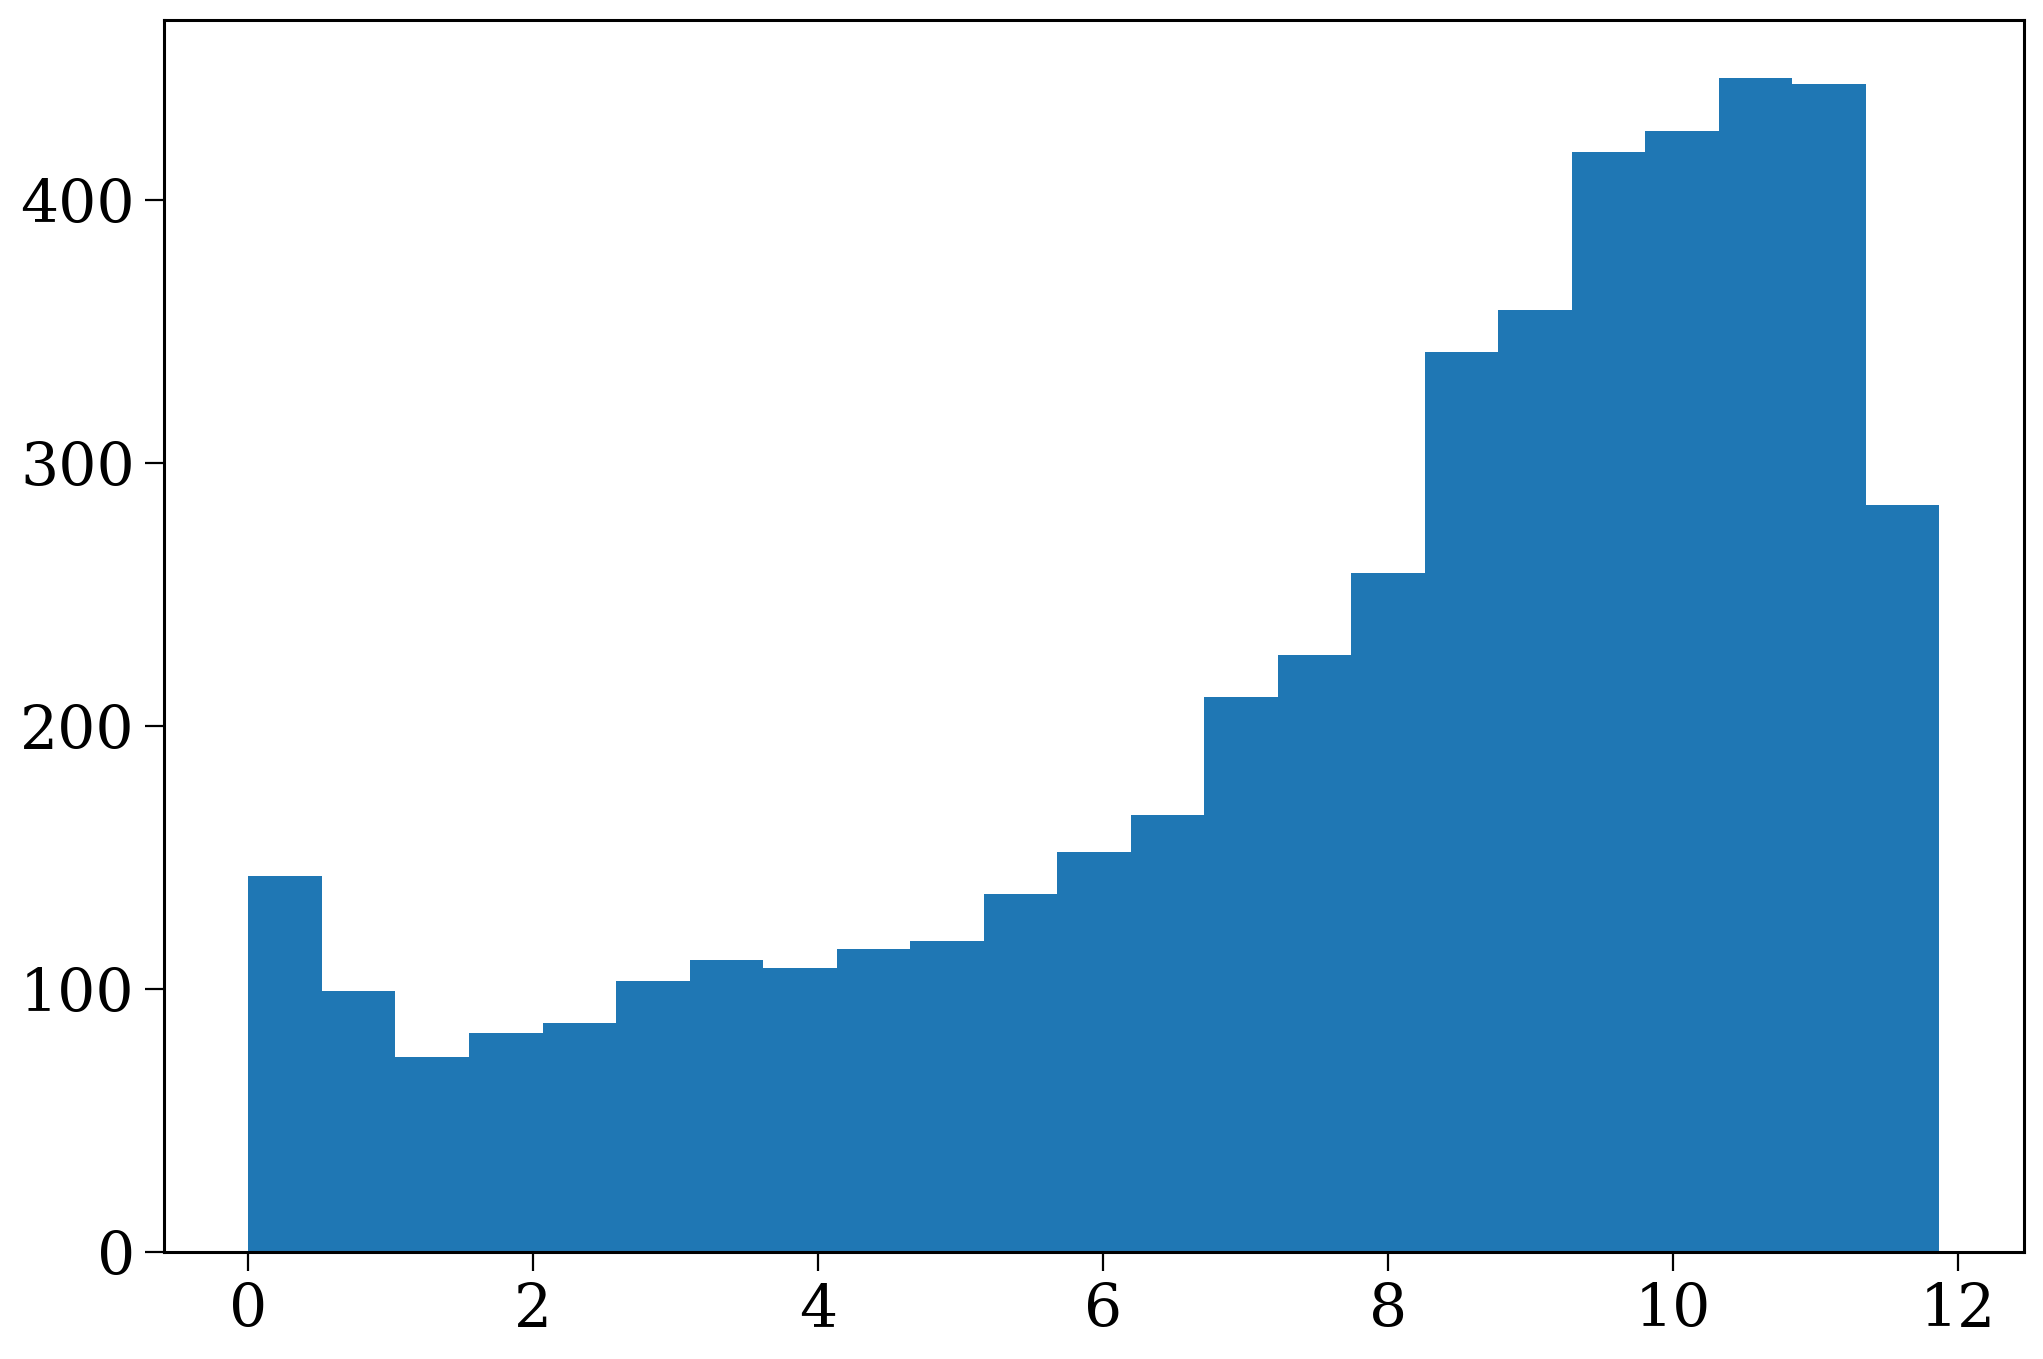

In [130]:
plt.hist(bh_star_pop.initial_galaxy.tau, bins="auto")

In [30]:
for pop in pops:
    if "companion" not in data[pop.label]:
        for key in ["n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"]:
            data[pop.label][key] = np.nan
        print("Skipping", pop.label)
        continue
    data[pop.label]["n_BH_star"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] < 10))
    data[pop.label]["n_BH_wd"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (np.isin(data[pop.label]["companion"]["BH"], [10, 11, 12])))
    data[pop.label]["n_BH_NS"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] == 13))
    data[pop.label]["n_BH_BH"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["primary"]["BH"]) & (data[pop.label]["companion"]["BH"] == 14))

    data[pop.label]["n_NS_star"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (data[pop.label]["companion"]["NS"] < 10))
    data[pop.label]["n_NS_wd"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (np.isin(data[pop.label]["companion"]["NS"], [10, 11, 12])))
    data[pop.label]["n_NS_NS"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (data[pop.label]["primary"]["NS"]) & (data[pop.label]["companion"]["NS"] == 13))

Skipping Time-evolving potential


In [6]:
reload(plotting)

scale_heights = []
scale_height_errs = []

for label in labels:
    sh, sh_err, _, _ = plotting.estimate_scale_height(
        z=np.abs(data[label]["pos"]["BH"][:, 2],),
        bins=np.linspace(0, 3, 201),
        plot=False,
        xlim=(0, 3),
        n_components=2
    )
    scale_heights.append(sh * 1000)
    scale_height_errs.append(sh_err * 1000)

In [35]:
stats = {
    "scale_up": [6e10 / data[label]["mass_binaries"] for label in labels],
    "n_BH": [data[label]["n_BH"] for label in labels],
    "m_BH": [sum(data[label]["mass"]["BH"]) for label in labels],
    "scale_height": scale_heights,
    "scale_height_err": scale_height_errs,
    r"$f_{\rm esc}$": [data[label]["escaped"]["BH"].sum() / len(data[label]["escaped"]["BH"])
                       for label in labels],
    r"$\langle m \rangle_{|z| < 1 \, {\rm kpc}}$": [data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) < 1) & ~(data[label]["escaped"]["BH"])].mean() for label in labels],
    r"$\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$": [data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) >= 1) & ~(data[label]["escaped"]["BH"])].mean() for label in labels],
    r"$f_{\rm bound}$": [(data[label]["sep"]["BH"] > 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm merger}$": [(data[label]["sep"]["BH"] == 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm unbound}$": [(data[label]["sep"]["BH"] < 0).sum() / data[label]["n_BH"] for label in labels],
    "n_BH_star": [data[label]["n_BH_star"] for label in labels],
    "n_BH_wd": [data[label]["n_BH_wd"] for label in labels],
    "n_BH_NS": [data[label]["n_BH_NS"] for label in labels],
    "n_BH_BH": [data[label]["n_BH_BH"] for label in labels],
    "n_NS_star": [data[label]["n_NS_star"] for label in labels],
    "n_NS_wd": [data[label]["n_NS_wd"] for label in labels],
    "n_NS_NS": [data[label]["n_NS_NS"] for label in labels],
    "n_NS_BH": [data[label]["n_NS_BH"] for label in labels],
}

df = pd.DataFrame(stats)
df.index = labels

# fix stats for singles because wide binaries make it funky
df.loc[r"$f_{\rm bin} = 0.0$", [r"$f_{\rm bound}$", r"$f_{\rm merger}$", r"$f_{\rm unbound}$", "n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"]] = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

for col, norm in zip(
    ["n_BH", "m_BH", "n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"],
    [1e8, 1e9, 1e3, 1e5, 1e5, 1e6, 1e4, 1e5, 1e4]
):
    df[col] *= df["scale_up"] / norm
del df["scale_up"]

latex_header = [r"$N_{\rm BH} / 10^8$", r"$M_{\rm BH} / 10^9 M_\odot$", r"$h_z$ (pc)", r"$\sigma_{h_z}$ (pc)"]
df.rename(columns=dict(zip(df.columns, latex_header)), inplace=True)
df.rename(columns={
    "n_BH_star": r"$N_{\rm BH\text{-}star} / 10^3$",
    "n_BH_wd": r"$N_{\rm BH\text{-}WD} / 10^5$",
    "n_BH_NS": r"$N_{\rm BH\text{-}NS} / 10^5$",
    "n_BH_BH": r"$N_{\rm BH\text{-}BH} / 10^6$",
    "n_NS_star": r"$N_{\rm NS\text{-}star} / 10^4$",
    "n_NS_wd": r"$N_{\rm NS\text{-}WD} / 10^5$",
    "n_NS_NS": r"$N_{\rm NS\text{-}NS} / 10^4$",
}, inplace=True)

df.round(2)

,$N_{\rm BH} / 10^8$,$M_{\rm BH} / 10^9 M_\odot$,$h_z$ (pc),$\sigma_{h_z}$ (pc),$f_{\rm esc}$,"$\langle m \rangle_{|z| < 1 \, {\rm kpc}}$","$\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$",$f_{\rm bound}$,$f_{\rm merger}$,$f_{\rm unbound}$,$N_{\rm BH\text{-}star} / 10^3$,$N_{\rm BH\text{-}WD} / 10^5$,$N_{\rm BH\text{-}NS} / 10^5$,$N_{\rm BH\text{-}BH} / 10^6$,$N_{\rm NS\text{-}star} / 10^4$,$N_{\rm NS\text{-}WD} / 10^5$,$N_{\rm NS\text{-}NS} / 10^4$,n_NS_BH
$f_{\rm bin} = 1.0$,1.87,1.72,549.07,14.45,0.03,10.06,7.68,0.05,0.65,0.30,6.31,3.66,1.46,4.05,5.75,4.11,2.23,1508.0
$f_{\rm bin} = 0.0$,1.70,1.48,625.39,15.36,0.03,9.66,7.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
No BH kicks,1.86,1.71,411.25,20.22,0.00,9.05,10.69,0.22,0.66,0.12,19.03,35.35,3.13,18.87,5.57,4.09,1.90,3225.0
No fallback rescaling,1.88,1.73,639.07,21.73,0.16,8.31,9.63,0.00,0.64,0.36,5.05,1.24,0.17,0.03,5.37,4.09,2.09,176.0
Hobbs2005,1.88,1.73,580.63,16.79,0.03,10.54,7.46,0.04,0.65,0.31,4.47,2.87,0.64,3.58,2.63,1.87,0.53,661.0
Fryer2012 Rapid,1.45,1.71,462.19,16.33,0.01,12.10,10.55,0.09,0.65,0.26,8.64,14.23,2.99,5.50,5.33,3.72,1.74,3074.0
Mandel\&Muller2020,2.33,2.12,384.13,19.58,0.00,9.16,8.43,0.17,0.67,0.16,66.42,45.46,1.03,17.21,4.43,3.11,0.27,1058.0
Maltsev2025 (Default),0.41,0.54,454.03,21.44,0.01,13.78,11.32,0.10,0.64,0.26,3.20,6.24,2.07,1.57,5.06,3.81,1.83,2132.0
$f_{\rm fb} = 0.0$,0.33,0.49,435.61,21.43,0.00,14.82,17.54,0.12,0.64,0.24,3.50,6.23,2.16,1.55,5.37,3.75,1.86,2223.0
$f_{\rm fb} = 0.25$,0.40,0.52,448.39,24.64,0.02,13.86,9.94,0.10,0.64,0.26,3.20,6.21,2.08,1.56,5.65,3.86,1.73,2138.0


# Main summary table

In [8]:
first_label_to_section = {
    r"$f_{\rm bin} = 1.0$": "Fiducial", "No BH kicks": "Supernova natal kicks",
    "Fryer2012 Rapid": "Remnant mass prescriptions",
    r"$f_{\rm fb} = 0.0$": "Maltsev2025 fallback mass fraction",
    r"$P({\rm pf}) = 0.0$": "Maltsev2025 partial fallback probability",
    "Time-evolving potential": "Galactic gravitational potential",
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
latex_table = r"""\begin{tabular}{lccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols[:-2]) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

for i, row in df.loc[main_labels].iterrows():
    if i in first_label_to_section:
        # add a small bit of vertical space before the section header
        latex_table += r"\addlinespace[0.5em]" + "\n"
        latex_table += r"\multicolumn{8}{l}{" + r"\textbf{" + first_label_to_section[i] + r"}} \\" + "\n"
    vals = row.values
    latex_table += r"\quad " + i + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f} \pm {vals[3]:.0f}$ & {vals[4] * 100:1.1f}\% & ${vals[5]:.2f}$ & ${vals[6]:.2f}$ & ${vals[7] * 100:1.0f}\%$ \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_z$ (pc) & $f_{\rm esc}$ & $\langle m \rangle_{|z| < 1 \, {\rm kpc}}$ & $\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$ & $f_{\rm bound}$ \\
\midrule
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Fiducial}} \\
\quad $f_{\rm bin} = 1.0$ & $1.87$ & $1.72$ & $549 \pm 14$ & 2.9\% & $10.06$ & $7.68$ & $5\%$ \\
\quad $f_{\rm bin} = 0.0$ & $1.70$ & $1.48$ & $625 \pm 15$ & 3.5\% & $9.66$ & $7.42$ & $0\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Supernova natal kicks}} \\
\quad No BH kicks & $1.86$ & $1.71$ & $411 \pm 20$ & 0.0\% & $9.05$ & $10.69$ & $22\%$ \\
\quad No fallback rescaling & $1.88$ & $1.73$ & $639 \pm 22$ & 16.2\% & $8.31$ & $9.63$ & $0\%$ \\
\quad Hobbs2005 & $1.88$ & $1.73$ & $581 \pm 17$ & 2.9\% & $10.54$ & $7.46$ & $4\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Remnant mass prescriptions}} \\
\quad Fryer2012 Rapid & $1.45$ & $1.71$ & $462 \pm 16$ & 0.7\% & $12.1

# Appendix MT summary plot

In [9]:
first_label_to_section = {
    r"$f_{\rm bin} = 1.0$": "Fiducial",
    r"$\beta = 0.0$": "Mass transfer efficiency",
    r"$\alpha_{\rm CE} = 0.1$": "Common-envelope efficiency",
    r"$q_{\rm crit, B} = 0$": "Mass transfer stability",
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
latex_table = r"""\begin{tabular}{lccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols[:-2]) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

for i, row in df.loc[mt_labels].iterrows():
    if i in first_label_to_section:
        # add a small bit of vertical space before the section header
        latex_table += r"\addlinespace[0.5em]" + "\n"
        latex_table += r"\multicolumn{8}{l}{" + r"\textbf{" + first_label_to_section[i] + r"}} \\" + "\n"
    vals = row.values
    latex_table += r"\quad " + i + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f} \pm {vals[3]:.0f}$ & {vals[4] * 100:1.1f}\% & ${vals[5]:.2f}$ & ${vals[6]:.2f}$ & ${vals[7] * 100:1.0f}\%$ \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_z$ (pc) & $f_{\rm esc}$ & $\langle m \rangle_{|z| < 1 \, {\rm kpc}}$ & $\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$ & $f_{\rm bound}$ \\
\midrule
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Fiducial}} \\
\quad $f_{\rm bin} = 1.0$ & $1.87$ & $1.72$ & $549 \pm 14$ & 2.9\% & $10.06$ & $7.68$ & $5\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Mass transfer efficiency}} \\
\quad $\beta = 0.0$ & $1.89$ & $1.91$ & $517 \pm 16$ & 2.8\% & $11.19$ & $7.96$ & $6\%$ \\
\quad $\beta = 0.5$ & $1.87$ & $1.71$ & $547 \pm 16$ & 2.9\% & $10.03$ & $7.67$ & $5\%$ \\
\quad $\beta = 1.0$ & $1.87$ & $1.71$ & $548 \pm 15$ & 2.9\% & $10.03$ & $7.67$ & $5\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Common-envelope efficiency}} \\
\quad $\alpha_{\rm CE} = 0.1$ & $1.94$ & $1.83$ & $546 \pm 16$ & 3.1\% & $10.27$ & $7.98$ & $4\%$ \\
\quad $\alpha_{\rm CE} = 0.5$ & $1.91$ & $1.77$ & $545 \pm 16$ & 

# Summary plot

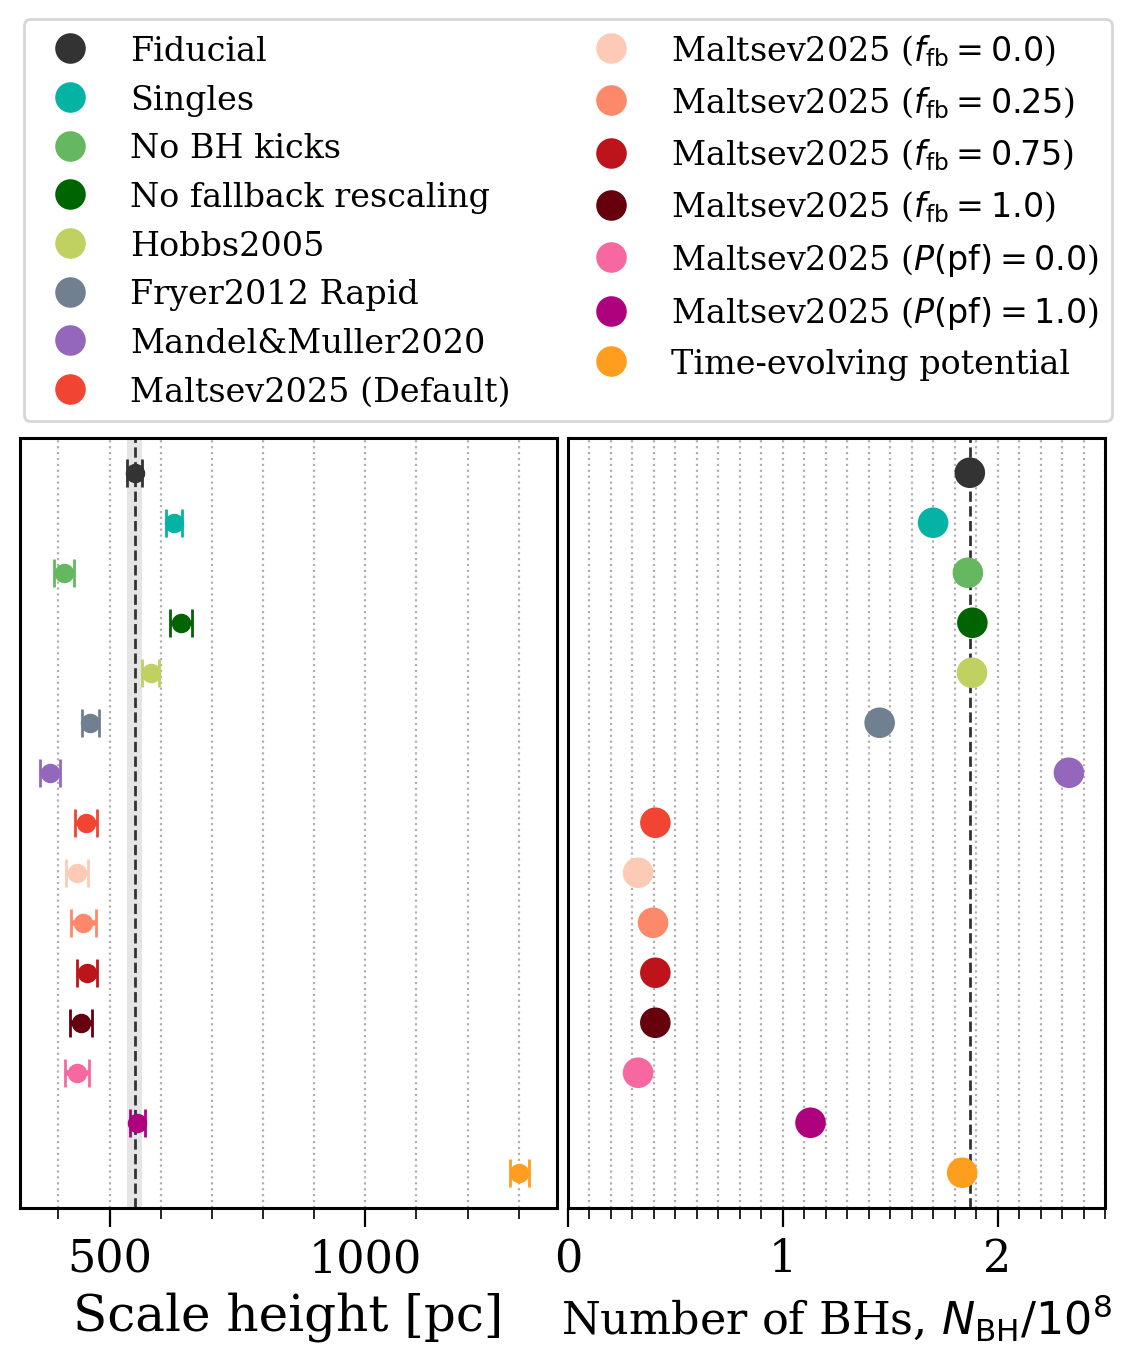

In [ ]:
reload(constants)

fig, axes = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

fig.subplots_adjust(wspace=0.02)

yticklabels = []

# make a scatter plot of the scale heights
ii = 0
for i, row in df.iterrows():
    if i == r"$\beta = 0.0$":
        break
    axes[0].errorbar(x=row["$h_z$ (pc)"], xerr=row["$\\sigma_{h_z}$ (pc)"], y=plot_labels[ii], color=constants.SIMULATION_COLOURS[ii], marker='o', markersize=6, capsize=5, lw=2)
    yticklabels.append(plot_labels[ii])
    ii += 1

# create a legend with the labels
handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker='o', linestyle='', markersize=10) for i in range(len(main_labels))]
axes[1].legend(handles, yticklabels, loc="lower center", fontsize=12, ncol=2, bbox_to_anchor=(0.0, 1.0))

axes[0].set(
    yticks=[]
)
axes[0].set_xlabel("Scale height [pc]", fontsize=18)

axes[0].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="#333", lw=1, ls="--")
axes[0].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", alpha=0.1, lw=0)
axes[0].invert_yaxis()
# axes[0].xaxis.set_major_locator(plt.MultipleLocator(100))
axes[0].xaxis.set_minor_locator(plt.MultipleLocator(100))


plot_df = df.loc[main_labels]
axes[1].scatter(plot_df["$N_{\\rm BH} / 10^8$"], [plot_labels[i] for i in range(len(main_labels))],
                color=[constants.SIMULATION_COLOURS[i] for i in range(len(main_labels))], zorder=10,
                s=100)
axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.1))
axes[1].axvline(plot_df["$N_{\\rm BH} / 10^8$"].values[0], color="#333", ls="--", zorder=-1, lw=1)

axes[0].set_xlim(325, 1375)
axes[1].set_xlim(0, 2.5)



axes[0].grid(True, which='both', axis='x', ls=':', zorder=-100)
axes[1].grid(True, which='both', axis='x', ls=':', zorder=-100)

for ax in axes:
    ax.tick_params(which='both', axis='x', labelsize=16)

plt.savefig("../plots/bh_summary_stats.pdf", format='pdf', bbox_inches='tight')

plt.show()

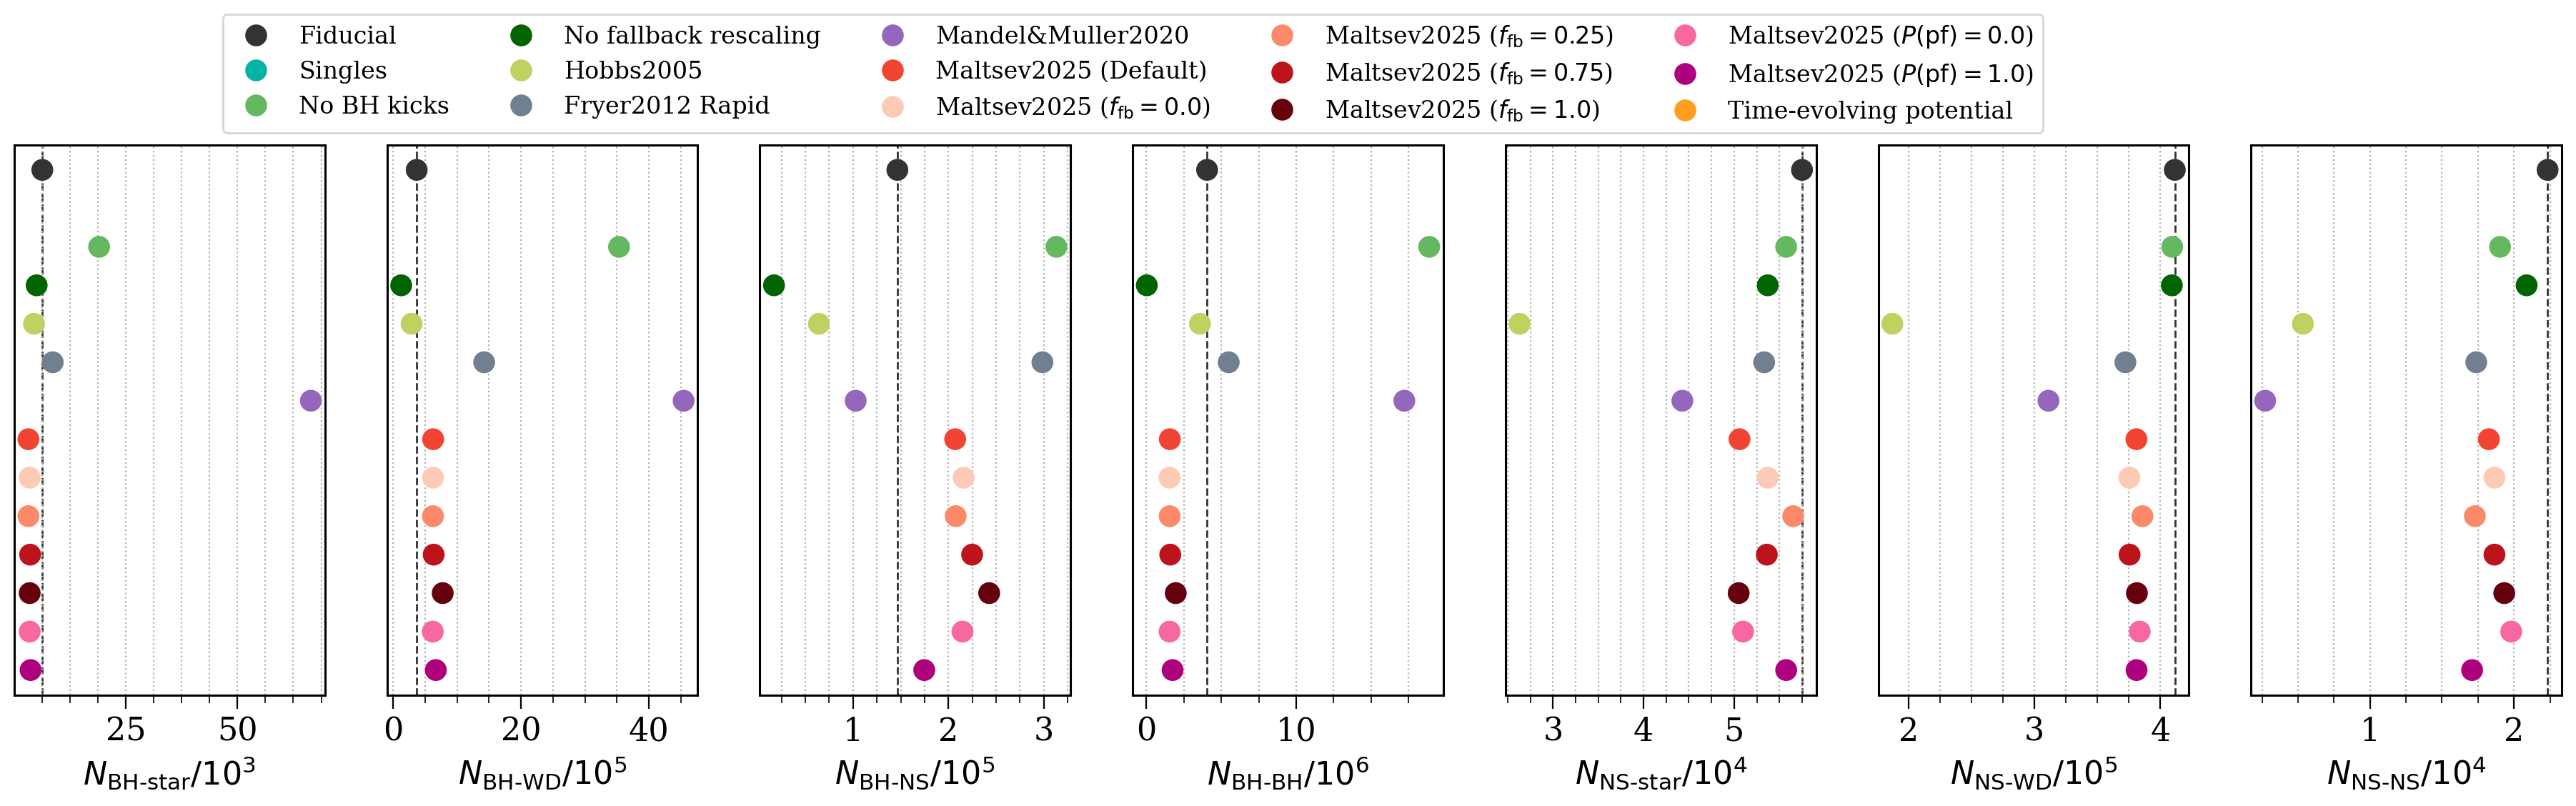

In [54]:
reload(constants)

fig, axes = plt.subplots(1, 7, figsize=(23, 5), sharey=True)

# fig.subplots_adjust(wspace=0.02)

# yticklabels = []

# # make a scatter plot of the scale heights
# ii = 0
# for i, row in df.iterrows():
#     if i == r"$\beta = 0.0$":
#         break
#     axes[0].errorbar(x=row["$h_z$ (pc)"], xerr=row["$\\sigma_{h_z}$ (pc)"], y=plot_labels[ii], color=constants.SIMULATION_COLOURS[ii], marker='o', markersize=6, capsize=5, lw=2)
#     yticklabels.append(plot_labels[ii])
#     ii += 1

# # create a legend with the labels
handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker='o', linestyle='', markersize=10) for i in range(len(main_labels))]
axes[3].legend(handles, plot_labels[:len(main_labels)], loc="lower center", fontsize=12, ncol=5, bbox_to_anchor=(0.0, 1.0))

for ax in axes:
    ax.tick_params(which='both', axis='x', labelsize=16)

# axes[0].set(
#     yticks=[]
# )

# axes[0].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="#333", lw=1, ls="--")
# axes[0].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", alpha=0.1, lw=0)
# axes[0].invert_yaxis()

for col, ax in zip(
    [r"$N_{\rm BH\text{-}star} / 10^3$", r"$N_{\rm BH\text{-}WD} / 10^5$", r"$N_{\rm BH\text{-}NS} / 10^5$", r"$N_{\rm BH\text{-}BH} / 10^6$", r"$N_{\rm NS\text{-}star} / 10^4$", r"$N_{\rm NS\text{-}WD} / 10^5$", r"$N_{\rm NS\text{-}NS} / 10^4$"],
    axes
):
    plot_df = df.loc[main_labels]
    ax.scatter(plot_df[col], [plot_labels[i] for i in range(len(main_labels))],
               color=[constants.SIMULATION_COLOURS[i] for i in range(len(main_labels))], zorder=10,
               s=100)
    ax.set_xlabel(col, fontsize=16)
    ax.axvline(plot_df[col].values[0], color="#333", ls="--", zorder=-1, lw=1)
    ax.xaxis.set_minor_locator(plt.MultipleLocator((ax.get_xticks()[1] - ax.get_xticks()[0]) / 4))

# plot_df = df.loc[main_labels]
# axes[1].scatter(plot_df["$N_{\\rm BH} / 10^8$"], [plot_labels[i] for i in range(len(main_labels))],
#                 color=[constants.SIMULATION_COLOURS[i] for i in range(len(main_labels))], zorder=10,
#                 s=100)
# axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
# axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
# axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.1))
# axes[1].axvline(plot_df["$N_{\\rm BH} / 10^8$"].values[0], color="#333", ls="--", zorder=-1, lw=1)

# axes[0].set_xlim(325, 1375)
# axes[1].set_xlim(0, 2.5)
axes[0].invert_yaxis()
axes[0].set_yticks([])

for ax in axes:
    ax.grid(True, which='both', axis='x', ls=':', zorder=-100)

# plt.savefig("../plots/bh_summary_stats.pdf", format='pdf', bbox_inches='tight')

plt.show()

['$f_{\\rm bin} = 1.0$',
 '$\\beta = 0.0$',
 '$\\beta = 0.5$',
 '$\\beta = 1.0$',
 '$\\alpha_{\\rm CE} = 0.1$',
 '$\\alpha_{\\rm CE} = 0.5$',
 '$\\alpha_{\\rm CE} = 2.0$',
 '$\\alpha_{\\rm CE} = 10.0$',
 '$q_{\\rm crit, B} = 0$',
 '$q_{\\rm crit, B} = \\infty$']

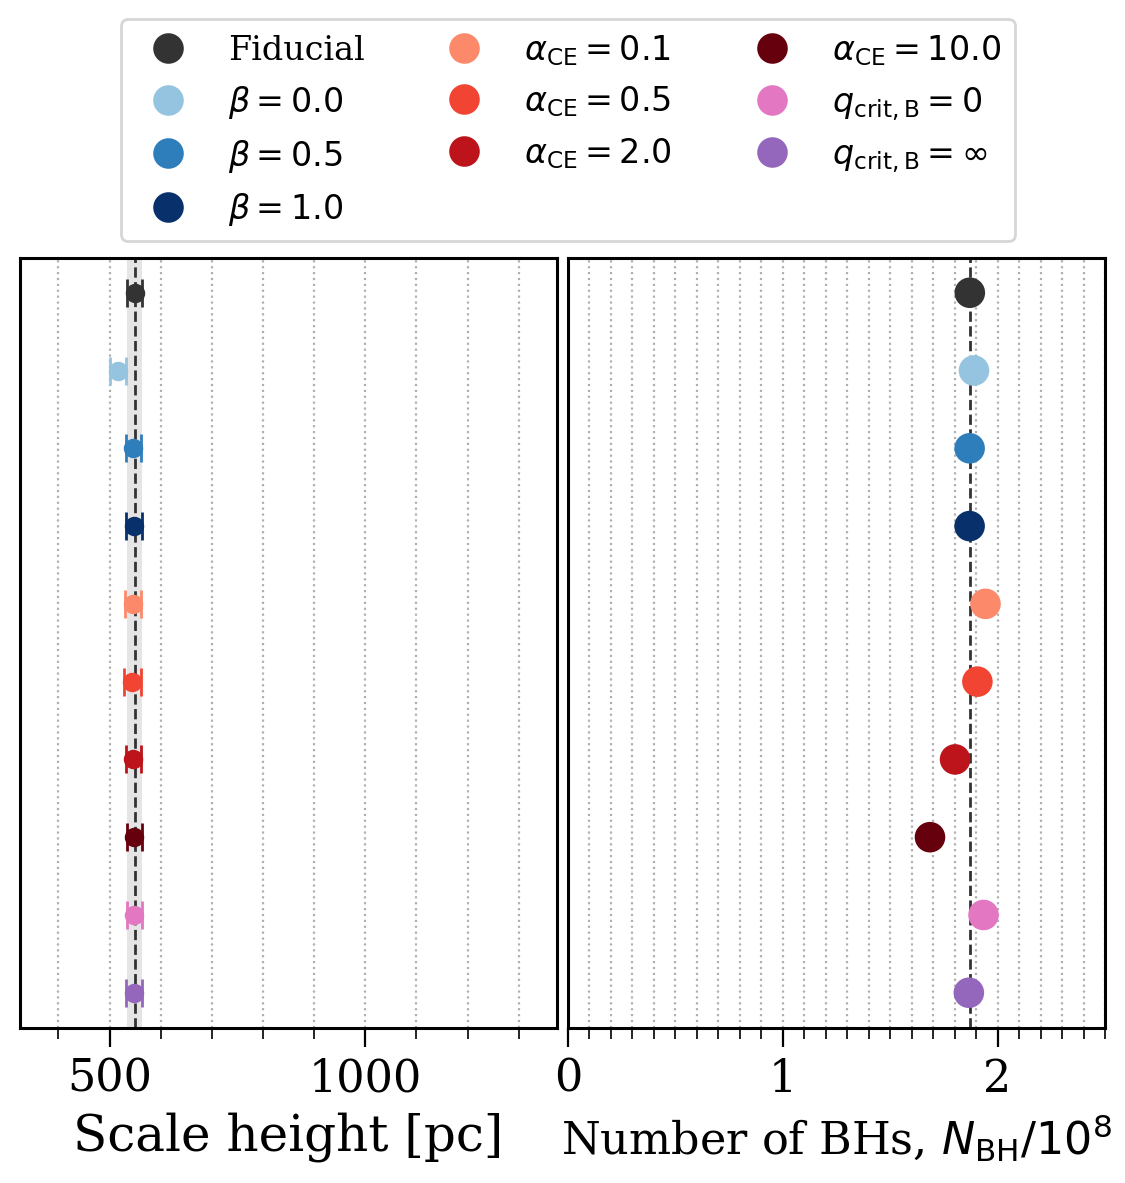

In [31]:
reload(constants)

fig, axes = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

fig.subplots_adjust(wspace=0.02)

yticklabels = []

plot_df = df.loc[mt_labels]
mt_labels_inds = [labels.index(label) for label in mt_labels]

# make a scatter plot of the scale heights
ii = 0
for i, row in plot_df.iterrows():
    axes[0].errorbar(x=row["$h_z$ (pc)"], xerr=row["$\\sigma_{h_z}$ (pc)"], y=plot_labels[mt_labels_inds[ii]], color=constants.SIMULATION_COLOURS[mt_labels_inds[ii]], marker='o', markersize=6, capsize=5, lw=2)
    yticklabels.append(plot_labels[mt_labels_inds[ii]])
    ii += 1

# create a legend with the labels
handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker='o', linestyle='', markersize=10) for i in mt_labels_inds]
axes[1].legend(handles, yticklabels, loc="lower center", fontsize=12, ncol=3, bbox_to_anchor=(0.0, 1.0))

axes[0].set(
    yticks=[]
)
axes[0].set_xlabel("Scale height [pc]", fontsize=18)

axes[0].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="#333", lw=1, ls="--")
axes[0].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", alpha=0.1, lw=0)
axes[0].invert_yaxis()
# axes[0].xaxis.set_major_locator(plt.MultipleLocator(100))
axes[0].xaxis.set_minor_locator(plt.MultipleLocator(100))



axes[1].scatter(plot_df["$N_{\\rm BH} / 10^8$"], [plot_labels[i] for i in mt_labels_inds],
                color=[constants.SIMULATION_COLOURS[i] for i in mt_labels_inds], zorder=10,
                s=100)
axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
axes[1].set_xlim(1.5, 2.0)
axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.1))
axes[1].axvline(plot_df["$N_{\\rm BH} / 10^8$"].values[0], color="#333", ls="--", zorder=-1, lw=1)


axes[0].grid(True, which='both', axis='x', ls=':', zorder=-100)
axes[1].grid(True, which='both', axis='x', ls=':', zorder=-100)

axes[0].set_xlim(325, 1375)
axes[1].set_xlim(0, 2.5)

for ax in axes:
    ax.tick_params(which='both', axis='x', labelsize=16)

plt.savefig("../plots/bh_summary_stats_mt.pdf", format='pdf', bbox_inches='tight')

plt.show()